In [1]:
!pip -q install nlpaug

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 5.0 MB/s eta 0:00:00


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import nlpaug.augmenter.word as naw

from tensorflow import keras
from tensorflow.keras import layers
from google.colab import drive

# Keeping the seed fixed so the splits and results stay more consistent
SEED = 21
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Loading the text dataset from the student wellness dataset
base_path = "/content/drive/MyDrive/student_wellness_multimodal_dataset/student_wellness_multimodal_dataset/text"

train_path = os.path.join(base_path, "train.csv")
test_path = os.path.join(base_path, "test.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (240, 4)
Test shape: (80, 4)


,sample_id,text,label,label_id
0,train_0000,I feel organized and balanced. My attendance i...,low_risk,0
1,train_0001,I missed a little sleep and spent more time st...,moderate_risk,1
2,train_0002,Lately I feel overwhelmed with classes and my ...,high_risk,2
3,train_0003,My sleep has been very poor and I am seriously...,critical_risk,3
4,train_0004,"My routine has been steady, I exercised a bit,...",low_risk,0


In [5]:
# Checking the column names
print(train_df.columns)
print("\nUnique labels in train set:")
print(train_df["label"].value_counts())

Index(['sample_id', 'text', 'label', 'label_id'], dtype='object')

Unique labels in train set:
label
low_risk         60
moderate_risk    60
high_risk        60
critical_risk    60
Name: count, dtype: int64


In [6]:
# Making a label mapping so the text labels become numeric classes
label_to_index = {
    label: idx for idx, label in enumerate(sorted(train_df["label"].unique()))
}

index_to_label = {idx: label for label, idx in label_to_index.items()}

train_df["label_id"] = train_df["label"].map(label_to_index)
test_df["label_id"] = test_df["label"].map(label_to_index)

print(label_to_index)

{'critical_risk': 0, 'high_risk': 1, 'low_risk': 2, 'moderate_risk': 3}


In [7]:
# Looking at a few sample text rows
for i in range(5):
    print(f"Text {i+1}: {train_df['text'].iloc[i]}")
    print(f"Label: {train_df['label'].iloc[i]}")
    print("-" * 60)

Text 1: I feel organized and balanced. My attendance is good and I do not feel too stressed. I usually sleep about 8.18 hours, study around 1.46 hours, and my stress feels like 29 out of 100.
Label: low_risk
------------------------------------------------------------
Text 2: I missed a little sleep and spent more time studying, so I feel somewhat tired lately. I usually sleep about 7.33 hours, study around 4.78 hours, and my stress feels like 56 out of 100.
Label: moderate_risk
------------------------------------------------------------
Text 3: Lately I feel overwhelmed with classes and my stress has been getting harder to manage. I usually sleep about 5.49 hours, study around 4.82 hours, and my stress feels like 68 out of 100.
Label: high_risk
------------------------------------------------------------
Text 4: My sleep has been very poor and I am seriously struggling to keep up with deadlines. I usually sleep about 5.88 hours, study around 6.09 hours, and my stress feels like 79 ou

In [8]:
# Splitting train into train and validation sets
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["text"].values,
    train_df["label_id"].values,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["label_id"].values
)

test_texts = test_df["text"].values
test_labels = test_df["label_id"].values

print("Train samples:", len(train_texts))
print("Validation samples:", len(val_texts))
print("Test samples:", len(test_texts))

Train samples: 192
Validation samples: 48
Test samples: 80


In [9]:
# Using TextVectorization to tokenize and vectorize the text
max_tokens = 5000
sequence_length = 40

vectorize_layer = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length
)

vectorize_layer.adapt(train_texts)

In [10]:
# This helper makes the text classifier so I can reuse the same model structure
def build_text_model():
    model = keras.Sequential([
        layers.Input(shape=(1,), dtype=tf.string),
        vectorize_layer,
        layers.Embedding(input_dim=max_tokens, output_dim=64),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(len(label_to_index), activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [11]:
# Training a baseline model without text augmentation
baseline_model = build_text_model()

history_baseline = baseline_model.fit(
    x=train_texts,
    y=train_labels,
    validation_data=(val_texts, val_labels),
    epochs=12,
    batch_size=16,
    verbose=0
)

baseline_test_loss, baseline_test_acc = baseline_model.evaluate(
    test_texts,
    test_labels,
    verbose=0
)

print("Baseline Test Accuracy:", round(baseline_test_acc, 4))

Baseline Test Accuracy: 1.0


In [12]:
# A very simple custom augmentation: randomly dropping one word from some sentences
def custom_text_augment(text):
    words = text.split()
    if len(words) > 4 and random.random() < 0.7:
        drop_index = random.randint(0, len(words) - 1)
        words.pop(drop_index)
    return " ".join(words)

custom_augmented_texts = [custom_text_augment(text) for text in train_texts]

for i in range(3):
    print("Original :", train_texts[i])
    print("Augmented:", custom_augmented_texts[i])
    print("-" * 60)

Original : I missed a little sleep and spent more time studying, so I feel somewhat tired lately. I usually sleep about 7.07 hours, study around 5.14 hours, and my stress feels like 40 out of 100.
Augmented: I missed a little sleep and spent more time studying, so I feel somewhat tired lately. I usually sleep about 7.07 hours, study around 5.14 hours, and my stress feels 40 out of 100.
------------------------------------------------------------
Original : I feel organized and balanced. My attendance is good and I do not feel too stressed. I usually sleep about 8.27 hours, study around 1.84 hours, and my stress feels like 16 out of 100.
Augmented: I feel organized and balanced. My attendance is good and I do not feel too stressed. I usually sleep about 8.27 hours, study around 1.84 hours, and my stress feels like 16 out of 100.
------------------------------------------------------------
Original : I feel burned out, behind in multiple classes, and my daily routine is not in a good pla

In [13]:
# Training with original + custom-augmented text
train_texts_custom_aug = np.concatenate([train_texts, np.array(custom_augmented_texts)])
train_labels_custom_aug = np.concatenate([train_labels, train_labels])

custom_aug_model = build_text_model()

history_custom_aug = custom_aug_model.fit(
    x=train_texts_custom_aug,
    y=train_labels_custom_aug,
    validation_data=(val_texts, val_labels),
    epochs=12,
    batch_size=16,
    verbose=0
)

custom_aug_test_loss, custom_aug_test_acc = custom_aug_model.evaluate(
    test_texts,
    test_labels,
    verbose=0
)

print("Custom Text Augmentation Test Accuracy:", round(custom_aug_test_acc, 4))

Custom Text Augmentation Test Accuracy: 1.0


In [14]:
# Using nlpaug synonym augmentation for a more standard NLP augmentation example
synonym_augmenter = naw.SynonymAug(aug_src="wordnet")

nlpaug_texts = []
for text in train_texts:
    try:
        augmented = synonym_augmenter.augment(text)
        if isinstance(augmented, list):
            augmented = augmented[0]
        nlpaug_texts.append(augmented)
    except:
        nlpaug_texts.append(text)

for i in range(3):
    print("Original :", train_texts[i])
    print("NLPAug   :", nlpaug_texts[i])
    print("-" * 60)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is al

Original : I missed a little sleep and spent more time studying, so I feel somewhat tired lately. I usually sleep about 7.07 hours, study around 5.14 hours, and my stress feels like 40 out of 100.
NLPAug   : I missed a little sleep and spent more time studying, so I feel somewhat tired lately. I usually sleep about 7.07 hours, study around 5.14 hours, and my stress feels like 40 out of 100.
------------------------------------------------------------
Original : I feel organized and balanced. My attendance is good and I do not feel too stressed. I usually sleep about 8.27 hours, study around 1.84 hours, and my stress feels like 16 out of 100.
NLPAug   : I feel organized and balanced. My attendance is good and I do not feel too stressed. I usually sleep about 8.27 hours, study around 1.84 hours, and my stress feels like 16 out of 100.
------------------------------------------------------------
Original : I feel burned out, behind in multiple classes, and my daily routine is not in a goo

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger t

In [15]:
# Training with original + nlpaug-augmented text
train_texts_nlpaug = np.concatenate([train_texts, np.array(nlpaug_texts)])
train_labels_nlpaug = np.concatenate([train_labels, train_labels])

nlpaug_model = build_text_model()

history_nlpaug = nlpaug_model.fit(
    x=train_texts_nlpaug,
    y=train_labels_nlpaug,
    validation_data=(val_texts, val_labels),
    epochs=12,
    batch_size=16,
    verbose=0
)

nlpaug_test_loss, nlpaug_test_acc = nlpaug_model.evaluate(
    test_texts,
    test_labels,
    verbose=0
)

print("NLPAug Test Accuracy:", round(nlpaug_test_acc, 4))

NLPAug Test Accuracy: 1.0


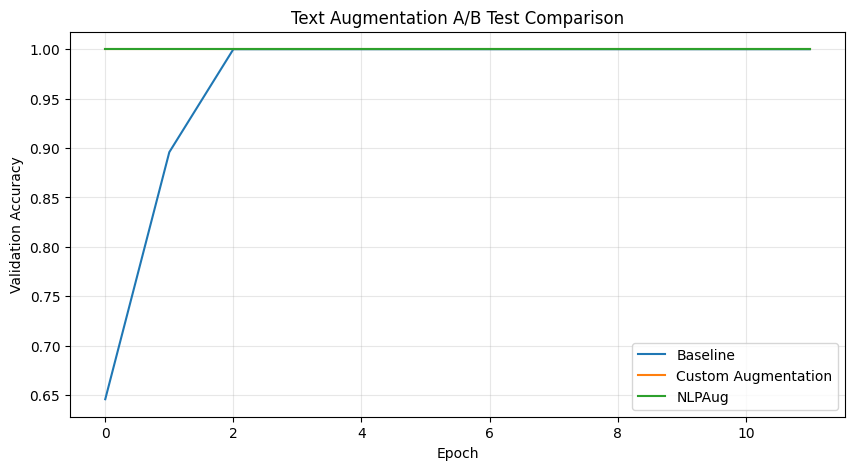

In [16]:
# Comparing the validation accuracy curves across the text experiments
plt.figure(figsize=(10, 5))
plt.plot(history_baseline.history["val_accuracy"], label="Baseline")
plt.plot(history_custom_aug.history["val_accuracy"], label="Custom Augmentation")
plt.plot(history_nlpaug.history["val_accuracy"], label="NLPAug")
plt.title("Text Augmentation A/B Test Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [17]:
# Looking at a few predictions from the best-performing text model
best_text_model = baseline_model
best_acc = baseline_test_acc

if custom_aug_test_acc > best_acc:
    best_text_model = custom_aug_model
    best_acc = custom_aug_test_acc

if nlpaug_test_acc > best_acc:
    best_text_model = nlpaug_model
    best_acc = nlpaug_test_acc

sample_predictions = best_text_model.predict(test_texts[:8], verbose=0)
predicted_classes = np.argmax(sample_predictions, axis=1)

for i in range(8):
    print("Text:", test_texts[i])
    print("True Label:", index_to_label[test_labels[i]])
    print("Predicted :", index_to_label[predicted_classes[i]])
    print("-" * 70)

Text: My routine has been steady, I exercised a bit, and overall I am handling my workload well. I usually sleep about 7.73 hours, study around 3.48 hours, and my stress feels like 13 out of 100.
True Label: low_risk
Predicted : low_risk
----------------------------------------------------------------------
Text: I am exhausted, very stressed, and I feel like everything is piling up at once. I usually sleep about 4.06 hours, study around 8.08 hours, and my stress feels like 73 out of 100.
True Label: critical_risk
Predicted : critical_risk
----------------------------------------------------------------------
Text: Lately I feel overwhelmed with classes and my stress has been getting harder to manage. I usually sleep about 4.48 hours, study around 5.22 hours, and my stress feels like 65 out of 100.
True Label: high_risk
Predicted : high_risk
----------------------------------------------------------------------
Text: This week was a little busy and I felt some stress building up, but I

In [18]:
# Final summary so the main results are easy to explain
print("Text Classification Results")
print("-" * 45)
print(f"Baseline Model        : {baseline_test_acc:.4f}")
print(f"Custom Augmentation   : {custom_aug_test_acc:.4f}")
print(f"NLPAug                : {nlpaug_test_acc:.4f}")

Text Classification Results
---------------------------------------------
Baseline Model        : 1.0000
Custom Augmentation   : 1.0000
NLPAug                : 1.0000


### Final Observation

In this notebook, I worked on text augmentation and text classification using the synthetic student wellness text dataset. I first trained a baseline text classifier, then compared it against a simple custom text augmentation method and an `nlpaug` synonym-based augmentation method. The main goal here was to see whether augmented text examples can help the model generalize better by exposing it to more variation in wording while keeping the same label.